In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2 
from tqdm import tqdm
import random

import warnings
warnings.filterwarnings("ignore")


os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers

import numpy as np
import collections
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import LearningRateSchedule


In [2]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available: 2


In [3]:
path = "/kaggle/input/hmu-gc-he-30k-normalized-macenko/Data/HMU-GC-HE-30K/all_image_normalized"
tissue_types = os.listdir(path)
tissue_types.sort()
tissue_types

['ADI_normalized',
 'DEB_normalized',
 'LYM_normalized',
 'MUC_normalized',
 'MUS_normalized',
 'NOR_normalized',
 'STR_normalized',
 'TUM_normalized']

ADI_normalized


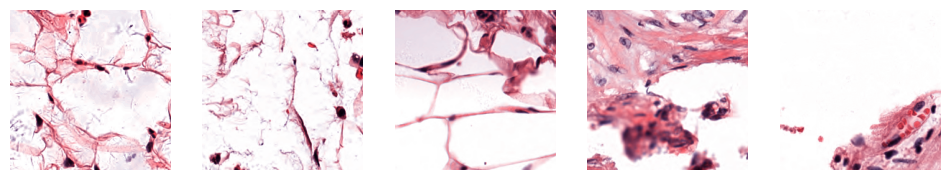

DEB_normalized


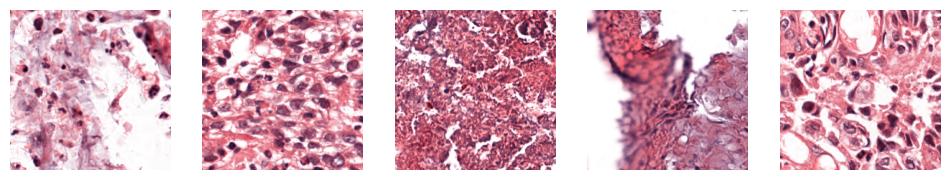

LYM_normalized


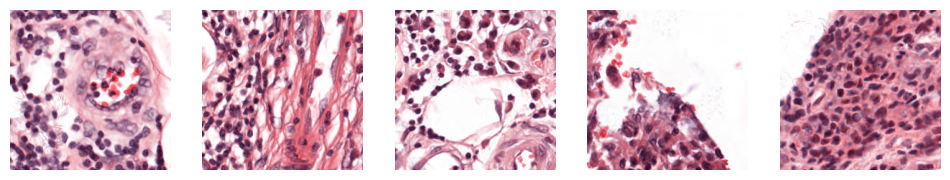

MUC_normalized


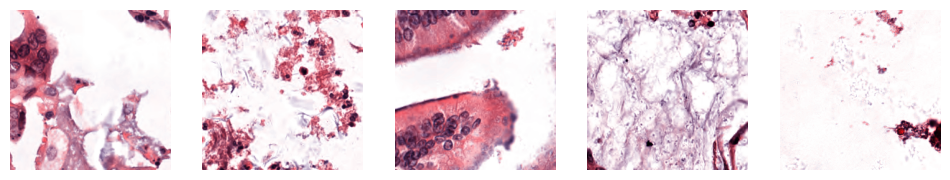

MUS_normalized


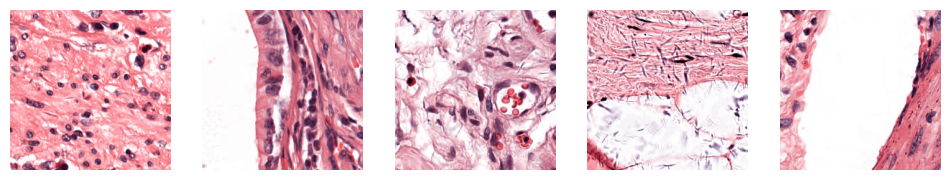

NOR_normalized


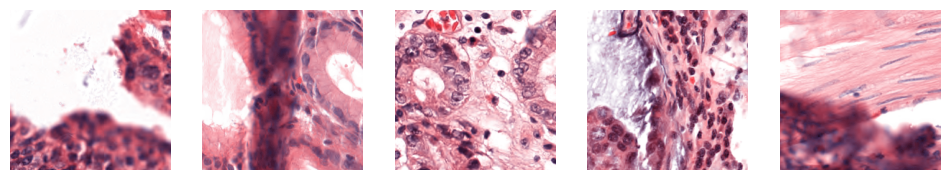

STR_normalized


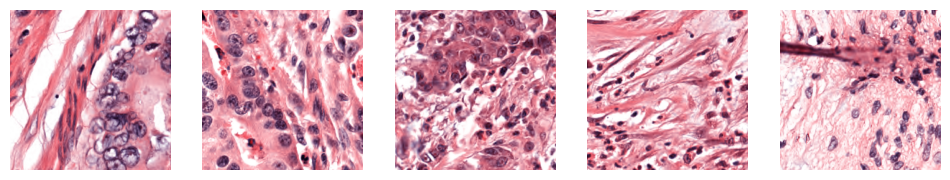

TUM_normalized


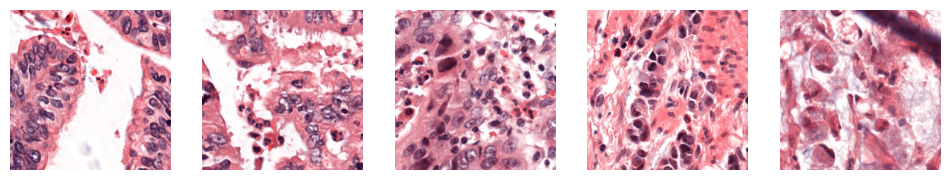

In [4]:
images_per_label = 5
for tissue in tissue_types:
    folder_path = os.path.join(path, tissue)
    folder_files = os.listdir(folder_path)
    random_ind=np.random.randint(0, len(folder_files),images_per_label)
    fig, ax = plt.subplots(1, images_per_label, figsize=(12, 10))
    print(tissue)
    for i, ind in enumerate(random_ind):     
        img = plt.imread(folder_path+'/'+folder_files[ind])
        ax[i].imshow(img)
        ax[i].axis('off')
    plt.show()



In [5]:
for tissue in tissue_types:
    folder_path = os.path.join(path, tissue)
    if os.path.isdir(folder_path):
        num_images = len([f for f in os.listdir(folder_path)])
        print(f"{tissue}: {num_images} images")

ADI_normalized: 3881 images
DEB_normalized: 3887 images
LYM_normalized: 3887 images
MUC_normalized: 3886 images
MUS_normalized: 3887 images
NOR_normalized: 3887 images
STR_normalized: 3887 images
TUM_normalized: 3887 images


In [6]:
# 85-15 split 

train_ds,val_ds = tf.keras.utils.image_dataset_from_directory(
  path,
  labels='inferred',
  validation_split=0.15,
  subset='both',
  seed=85,
  batch_size=32,
  image_size=(224, 224),
  shuffle=True
  )


Found 31090 files belonging to 8 classes.
Using 26427 files for training.
Using 4663 files for validation.


In [7]:
train_ds.class_names

['ADI_normalized',
 'DEB_normalized',
 'LYM_normalized',
 'MUC_normalized',
 'MUS_normalized',
 'NOR_normalized',
 'STR_normalized',
 'TUM_normalized']

In [8]:
image, label = next(iter(train_ds))
print(image.shape)
print(label.shape)

(32, 224, 224, 3)
(32,)


In [9]:
train_labels = []
for _, labels in train_ds:
    train_labels.extend(labels.numpy())

train_label_counts = collections.Counter(train_labels)
print("Train label distribution:")
print(dict(sorted(train_label_counts.items())))

val_labels = []
for _, labels in val_ds:
    val_labels.extend(labels.numpy())

val_label_counts = collections.Counter(val_labels)
print("\nValidation label distribution:")
print(dict(sorted(val_label_counts.items())))

Train label distribution:
{0: 3326, 1: 3298, 2: 3316, 3: 3314, 4: 3279, 5: 3305, 6: 3314, 7: 3275}

Validation label distribution:
{0: 556, 1: 589, 2: 571, 3: 572, 4: 608, 5: 582, 6: 573, 7: 612}


In [10]:
def preprocess(image, label):
    image = tf.keras.applications.efficientnet.preprocess_input(image)
    return image, label


In [11]:
train_ds_clean = train_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)
val_ds_clean = val_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)


In [12]:
# save the number of class labels
num_labels=len(train_ds.class_names)

In [13]:
from tensorflow.keras.applications import EfficientNetB0,Xception,EfficientNetB1,EfficientNetB3

input_tensor = tf.keras.Input(shape=(224, 224, 3))
base_model = tf.keras.applications.EfficientNetB3(weights="imagenet", include_top=False, input_tensor=input_tensor)
x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
output = tf.keras.layers.Dense(8, activation="softmax")(x)
model = tf.keras.Model(inputs=input_tensor, outputs=output)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [14]:
for layer in base_model.layers:
    layer.trainable = True
#for layer in base_model.layers[-60:]:
   # layer.trainable = True

In [15]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

early_stopping = tf.keras.callbacks.EarlyStopping(
    min_delta=0.005, # minimium amount of change to count as an improvement
    patience=4, # how many epochs to wait before stopping
    restore_best_weights=True
)

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    "/kaggle/working/efficientnetb3_baseline_macenko_normalized.h5",
    save_best_only=True,
    monitor="val_loss",
    mode="min"
)
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',     
    factor=0.3,             
    patience=3,            
    verbose=1,              
    min_lr=1e-6           
)



In [17]:
optimizer = tf.keras.optimizers.SGD(learning_rate=3e-4, momentum=0.9)
model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=["accuracy"])
history = model.fit(train_ds_clean, epochs=30, validation_data=val_ds_clean, callbacks=[early_stopping, checkpoint_callback,lr_scheduler])

Epoch 1/30
826/826 ━━━━━━━━━━━━━━━━━━━━ 358s 322ms/step - accuracy: 0.5571 - loss: 1.2072 - val_accuracy: 0.6058 - val_loss: 1.0692 - learning_rate: 3.0000e-04
Epoch 2/30
826/826 ━━━━━━━━━━━━━━━━━━━━ 213s 258ms/step - accuracy: 0.6100 - loss: 1.0664 - val_accuracy: 0.6316 - val_loss: 0.9954 - learning_rate: 3.0000e-04
Epoch 3/30
826/826 ━━━━━━━━━━━━━━━━━━━━ 212s 257ms/step - accuracy: 0.6404 - loss: 0.9773 - val_accuracy: 0.6472 - val_loss: 0.9541 - learning_rate: 3.0000e-04
Epoch 4/30
826/826 ━━━━━━━━━━━━━━━━━━━━ 212s 257ms/step - accuracy: 0.6597 - loss: 0.9230 - val_accuracy: 0.6579 - val_loss: 0.9241 - learning_rate: 3.0000e-04
Epoch 5/30
826/826 ━━━━━━━━━━━━━━━━━━━━ 212s 257ms/step - accuracy: 0.6733 - loss: 0.8833 - val_accuracy: 0.6682 - val_loss: 0.8998 - learning_rate: 3.0000e-04
Epoch 6/30
826/826 ━━━━━━━━━━━━━━━━━━━━ 212s 257ms/step - accuracy: 0.6941 - loss: 0.8347 - val_accuracy: 0.6740 - val_loss: 0.8814 - learning_rate: 3.0000e-04
Epoch 7/30
826/826 ━━━━━━━━━━━━━━━━━━━━ 

In [18]:
from tensorflow.keras.models import load_model
best_model = load_model("/kaggle/working/efficientnetb3_baseline_macenko_normalized.h5")
loss, acc = best_model.evaluate(val_ds_clean, verbose=0)
print(f"Saved model - val_loss: {loss:.4f}, val_accuracy: {acc:.4f}")

Saved model - val_loss: 0.8410, val_accuracy: 0.6916


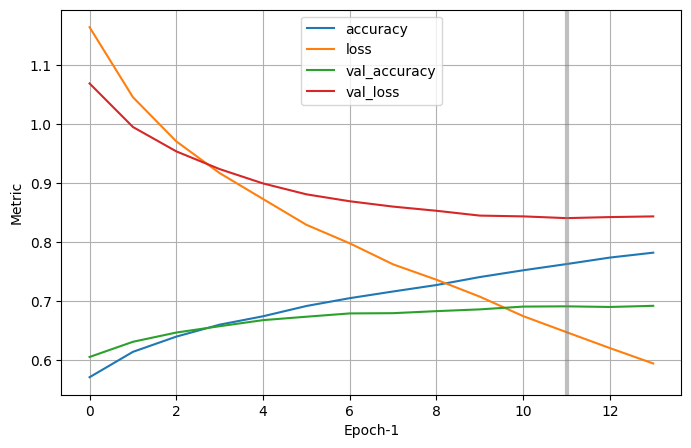

In [24]:
df = pd.DataFrame(history.history)
if 'learning_rate' in df.columns:
    df = df.drop(columns=['learning_rate'])

df.plot(figsize=(8, 5))
plt.axvline(11, lw=3, color='grey', alpha=0.5)
plt.grid(True)
plt.xlabel("Epoch-1")
plt.ylabel("Metric")
plt.show()

In [26]:
from sklearn.metrics import roc_auc_score

y_pred_probs = best_model.predict(val_ds_clean)
y_true = np.concatenate([y for x, y in val_ds_clean], axis=0)

# Compute AUC
auc = roc_auc_score(y_true, y_pred_probs, multi_class='ovr')
print(f"AUC: {auc:.4f}")


146/146 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step
AUC: 0.9471


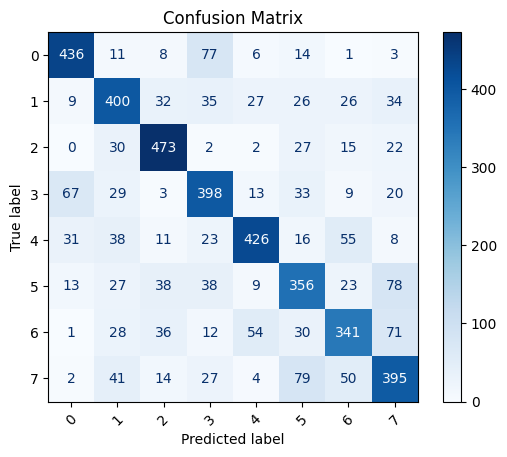

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
y_pred = np.argmax(y_pred_probs, axis=1)
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [28]:
from sklearn.metrics import classification_report
report = classification_report(y_true, y_pred, digits=4)
print(report)

              precision    recall  f1-score   support

           0     0.7800    0.7842    0.7821       556
           1     0.6623    0.6791    0.6706       589
           2     0.7691    0.8284    0.7976       571
           3     0.6503    0.6958    0.6723       572
           4     0.7874    0.7007    0.7415       608
           5     0.6127    0.6117    0.6122       582
           6     0.6558    0.5951    0.6240       573
           7     0.6260    0.6454    0.6356       612

    accuracy                         0.6916      4663
   macro avg     0.6929    0.6925    0.6920      4663
weighted avg     0.6925    0.6916    0.6913      4663

